# The Short-Time Fourier Transform (STFT)

- The Fourier Transform provides **frequency** information of a signal that represents frequencies and their magnitude.

- It does not tell us when in time the frequencies exist. The transform is therefore ideal for **stationary signals**.

- Lacks capability to provide frequency information for a localized signal region in **time**.

## Short-time Fourier transform:
                                                   

- The STFT was developed to overcome the poor time resolution of the Fourier Transform. It gives us a **time-frequency** representation of the signal.

- With STFT we can assume some **portion** of the non-stationary signal is **stationary**.

- We then take a Fourier Transform of each stationary portion along the signal and add them up.


We need a method that catches characteristic frequencies at different times. A method that shifts the Fourier transform in time, to specific windows in time. 



The method is called a **Short-time Fourier transform (STFT)**. It assumes some portion of the non-stationary signal is stationary and takes a FFT of each portion. At the end, we make a representation in the time-frequency domain.

$$
\begin{equation}
X(\tau, \omega) = \int_{-\infty}^{\infty} x(t) w(t - \tau) e^{-i \omega t} \, dt
\end{equation}
$$

We take a window function of fixed length and move it along the signal, by the translation parameter $\tau$. But this is a limitation, it should adapt to the the different sections of the signal. We would not capture all frequencies with the same resolution. Also, this fixed length of the window implies that time and frequency resolutions are fixed for the entire domain.
$$
\Rightarrow \Delta t \Delta \nu \geq \frac{1}{4 \pi}
$$

We don't know what frequency exists at what instance, what we get is frequency bands that exist at particular time intervals.


# Wavelet transforms

It allows us to analyse a signal into different frequencies at different time resolutions by using a window function called a wavelet (also called wavepacket. It can be shifted, shrunken (capture details of the signal) and stretched (capture overall trend of the signal).
Set of methods to carry out spectral analysis in the time domain, it's a multi-resolution analysis.

$$
\begin{equation}
X(\tau, s) = \frac{1}{\sqrt{|s|}} \int_{-\infty}^{\infty} x(t) \, {\psi^*\left( \frac{t - \tau}{s} \right)} \, dt
\end{equation}
$$

$s$ is the scaling parameter, it has units of time.

$\tau$ is the translation parameter, it has units of time.

The window function is obtained from the wavelet $\psi$, which can have different forms. The window functions are stretched or compressed and shifted versions of the chosen wavelet.

The **basis functions** for the wavelet transform are **wavelets**, while for the Fourier transform the basis functions are sine and cosine functions. Wavelets transforms should be used for non-stationary signals.


## Wavelet types:

####  https://pywavelets.readthedocs.io/en/latest


In [5]:
import pywt

import numpy as np
import matplotlib.pyplot as plt

In [6]:
print(pywt.wavelist(kind = "discrete"))

['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'haar', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', 'sym2', 'sym3', 'sym4', 'sym5', 'sym6', 'sym7', 'sym8', 'sym9', 'sym10', 'sym11', 'sym12', 'sym13', 'sym14', 'sym15', 'sym16', 'sym17', 'sym18', 'sym19', 'sym20']


In [7]:
print(pywt.wavelist(kind = "continuous"))

['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']


### Plotting wavelets:

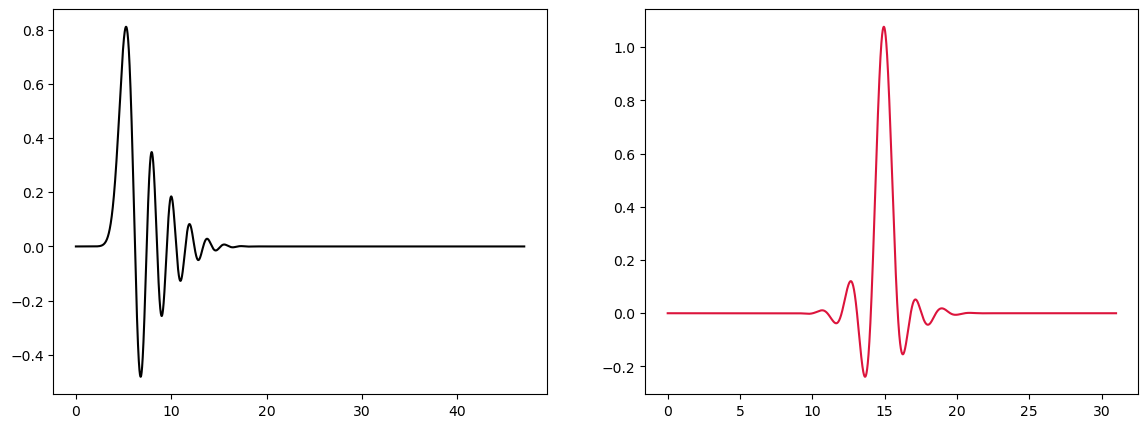

In [11]:
# 2 wavelets
w2 = pywt.Wavelet("db24") #get the properties
w3 = pywt.Wavelet("sym16")

# Plotting
# Gather information on wavelet
phi_2, psi_2, x_2 = w2.wavefun(level = 10)
phi_3, psi_3, x_3 = w3.wavefun(level = 10)

# Figure env
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))
ax1.plot(x_2, phi_2, color = "black")
ax2.plot(x_3, phi_3, color = "crimson")
plt.show()

### Print wavelet information:

In [13]:
print("Print information on the wavelet: \n", w2)

Print information on the wavelet: 
 Wavelet db24
  Family name:    Daubechies
  Short name:     db
  Filters length: 48
  Orthogonal:     True
  Biorthogonal:   True
  Symmetry:       asymmetric
  DWT:            True
  CWT:            False


/var/folders/lk/z3g6vdb52msdt9x8k77krt080000gn/T/ipykernel_65262/168881178.py:5: FutureWarning: Wavelets from the family shan, without parameters specified in the name are deprecated. The name should takethe form shanB-C where B and C are floats representing the bandwidth frequency and center frequency, respectively (example: shan1.5-1.0).
  w5 = pywt.ContinuousWavelet("shan")


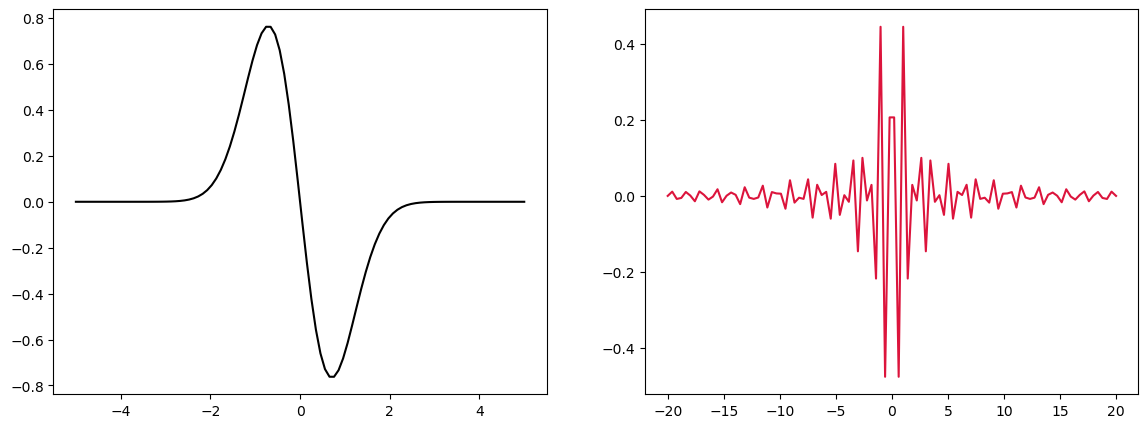

In [19]:
# 2 wavelets

# 2 wavelets
w4 = pywt.ContinuousWavelet("gaus1") #get the properties
w5 = pywt.ContinuousWavelet("shan")

# Plotting
# Gather information on wavelet
psi_4, x_4 = w4.wavefun(length = 100)
psi_5, x_5 = w5.wavefun(length = 100)

# Figure env
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))
ax1.plot(x_4, psi_4, color = "black")
ax2.plot(x_5, psi_5, color = "crimson")
plt.show()

In [20]:
print("Print information on the wavelet: \n", w4)

Print information on the wavelet: 
 ContinuousWavelet gaus1
  Family name:    Gaussian
  Short name:     gaus
  Symmetry:       anti-symmetric
  DWT:            False
  CWT:            True
  Complex CWT:    False
